# 06 — Real WTI Futures Data: Exploratory Figures for the Thesis

This notebook produces **publication-quality figures** describing the real WTI
crude-oil futures dataset that feeds the Gibson–Schwartz PINN inversion.

The data live in `src/gs_wamol/data/processed_data/`:

| File | Contents | Role in the model |
|------|----------|-------------------|
| `wti_daily_state.csv`  | `date, spot, rate` (daily, 2015→2026) | the state $(S_t, r_t)$ |
| `wti_futures_panel.csv`| `date, contract, tau, settle, volume, expiry` | the observable term structure |
| `wti_analysis_ready.csv` | panel joined to state | convenience view |

**Design choice.** The reference gold figure colours its 3-D ribbon by an
*external* volatility index (GVZ). Our thesis target is the **latent convenience
yield** $\delta_t$, so wherever the reference used colour to encode "market
stress", we instead encode a **model-free convenience-yield proxy** derived from
the slope of the log-futures curve. This ties every picture back to the quantity
the PINN actually inverts for.

> **Model-free $\delta$ proxy.** To first order the cost-of-carry relation gives
> $\ln F(\tau) \approx \ln S + (r-\delta)\,\tau$, so the **slope of the
> log-futures curve in $\tau$** is $\approx r-\delta$. Hence
> $\;\hat\delta_t \;=\; r_t - \dfrac{\partial \ln F}{\partial \tau}\Big|_{\tau\to 0}$.
> This single-factor approximation is *deliberately naïve* — its shortcomings are
> exactly what motivate the two-factor Gibson–Schwartz model and the PINN.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from pathlib import Path

# --- publication style ------------------------------------------------------
# Higher DPI + serif to sit comfortably next to LaTeX body text; grid behind data.
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,          # crisp raster fallback; we also save vector PDF
    "font.size": 10,
    "font.family": "serif",
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
CMAP = "viridis"                 # matches the reference figure's perceptual map

# --- paths ------------------------------------------------------------------
# Notebook lives in notebooks/; data two levels up under src/.
ROOT   = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA   = ROOT / "src" / "gs_wamol" / "data" / "processed_data"
FIGDIR = ROOT / "notebooks" / "figures" / "data"
FIGDIR.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    "Save each figure as vector PDF (for the thesis) + PNG (for quick preview)."
    fig.savefig(FIGDIR / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(FIGDIR / f"{name}.png", bbox_inches="tight")
    print("saved", FIGDIR / f"{name}.{{pdf,png}}")

print("data dir:", DATA, "| exists:", DATA.exists())

data dir: /Users/evanlynch/Developer/DC-PINNs/src/gs_wamol/data/processed_data | exists: True


## 0. Load and shape the data

`state` is one row per trading day. `panel` is *long* format: one row per
`(date, contract)` — i.e. 6–9 rows per day, one for each live maturity. Keeping
it long (rather than pivoting to a wide `date × maturity` matrix) is the right
call here because the set of live maturities **changes every day** as contracts
expire and roll — a wide matrix would be mostly `NaN`.

In [10]:
state = pd.read_csv(DATA / "wti_daily_state.csv",   parse_dates=["date"])
panel = pd.read_csv(DATA / "wti_futures_panel.csv",
                    parse_dates=["date", "expiry"])

state = state.sort_values("date").reset_index(drop=True)
panel = panel.sort_values(["date", "tau"]).reset_index(drop=True)

print(f"state : {len(state):>6} rows | {state.date.min():%Y-%m-%d} -> {state.date.max():%Y-%m-%d}")
print(f"panel : {len(panel):>6} rows | {panel.contract.nunique()} contracts | "
      f"{panel.groupby('date').size().min()}-{panel.groupby('date').size().max()} maturities/day")
panel.head()

state :   2892 rows | 2015-01-02 -> 2026-06-30
panel :  22985 rows | 52 contracts | 6-9 maturities/day


,date,contract,ric,tau,settle,volume,expiry
0,2015-01-02,CLH2015,CLH5^1,0.134247,53.11,66396.0,2015-02-20
1,2015-01-02,CLM2015,CLM5^1,0.375342,55.15,28953.0,2015-05-19
2,2015-01-02,CLU2015,CLU5^1,0.630137,57.07,2980.0,2015-08-20
3,2015-01-02,CLZ2015,CLZ5^1,0.882192,59.05,16219.0,2015-11-20
4,2015-01-02,CLH2016,CLH6^1,1.139726,60.60,272.0,2016-02-22


## 1. Derive the model-free convenience-yield proxy

For each date we regress $\ln F_i$ on $\tau_i$ across the live maturities. The
fitted **slope** $m$ estimates $r-\delta$, so $\hat\delta = r - m$.

**Shape tracking.** Per date we have a small vector $(\tau_i, F_i)$ of length
$M_t\in[6,9]$. We fit a degree-1 polynomial → 2 coefficients; the slope is the
one we keep. We also record the **front-month basis** $F_{\text{front}}/S - 1$,
a second, even simpler backwardation gauge used later for colour.

> **Gotcha (why not just use two points).** Using only the two nearest contracts
> makes the slope hostage to a single noisy quote. A least-squares fit over *all*
> live maturities is far more stable — a small illustration of why the full-curve
> PINN should beat a front-spread heuristic.

In [11]:
def per_date_features(g):
    "Collapse one date's live curve into scalar term-structure features."
    tau = g["tau"].to_numpy()
    F   = g["settle"].to_numpy()
    # Least-squares slope of ln F vs tau across ALL live maturities (robust to
    # a single bad quote). polyfit returns [slope, intercept] for degree 1.
    slope = np.polyfit(tau, np.log(F), 1)[0]        # ≈ (r - delta)
    front = F[np.argmin(tau)]                        # nearest-to-expiry settle
    back  = F[np.argmax(tau)]                        # longest maturity settle
    return pd.Series({"logF_slope": slope,
                      "front_settle": front,
                      "curve_spread": back - front}) # >0 contango, <0 backwardation

feat = (panel.groupby("date").apply(per_date_features, include_groups=False)
             .reset_index())

# Attach the state so we can turn the slope into a delta proxy: delta ≈ r - slope.
df = feat.merge(state, on="date", how="left")
df["delta_proxy"] = df["rate"] - df["logF_slope"]
df["front_basis"] = df["front_settle"] / df["spot"] - 1.0   # simple carry gauge

print(df[["date", "spot", "rate", "logF_slope", "delta_proxy",
          "curve_spread"]].describe(percentiles=[.1, .5, .9]).round(3))
df.head()

                             date      spot      rate  logF_slope  \
count                        2891  2890.000  2890.000    2891.000   
mean   2020-09-28 06:26:01.535800    63.158     0.021      -0.022   
min           2015-01-02 00:00:00    10.010     0.000      -0.251   
10%           2016-02-26 00:00:00    42.226     0.000      -0.097   
50%           2020-09-28 00:00:00    61.855     0.016      -0.039   
90%           2025-05-05 00:00:00    85.554     0.054       0.076   
max           2026-06-29 00:00:00   123.700     0.056       0.457   
std                           NaN    17.740     0.020       0.074   

       delta_proxy  curve_spread  
count     2890.000      2891.000  
mean         0.043        -3.523  
min         -0.456       -36.200  
10%         -0.074       -12.880  
50%          0.067        -4.050  
90%          0.130         6.890  
max          0.287        21.900  
std          0.084         8.253  


,date,logF_slope,front_settle,curve_spread,spot,rate,delta_proxy,front_basis
0,2015-01-02,0.111455,53.11,11.52,52.69,0.0002,-0.111255,0.007971
1,2015-01-05,0.126181,50.52,12.56,50.04,0.0003,-0.125881,0.009592
2,2015-01-06,0.128748,48.46,12.43,47.93,0.0003,-0.128448,0.011058
3,2015-01-07,0.118489,49.08,11.49,48.65,0.0003,-0.118189,0.008839
4,2015-01-08,0.116446,49.28,11.37,48.79,0.0003,-0.116146,0.010043


## Figure 1 — Market state: spot $S_t$ and risk-free rate $r_t$

The two exogenous inputs to Gibson–Schwartz pricing. Three regimes recur
throughout the dataset and reappear in every later figure:

- **2016** — post-glut trough (~\$30);
- **2020** — the COVID demand collapse (WTI to ~\$10, historic *super-contango*
  as storage filled → deeply **negative** convenience yield);
- **2022** — the post-invasion spike (~\$120), pronounced **backwardation**
  (high $\delta$), and the rate-hiking cycle.

We colour the spot line by the **convenience-yield proxy** so the reader
immediately associates high $\delta$ with backwardated, scarcity-driven markets
and negative $\delta$ with glutted, contango markets.

saved /Users/evanlynch/Developer/DC-PINNs/notebooks/figures/data/fig1_market_state.{pdf,png}


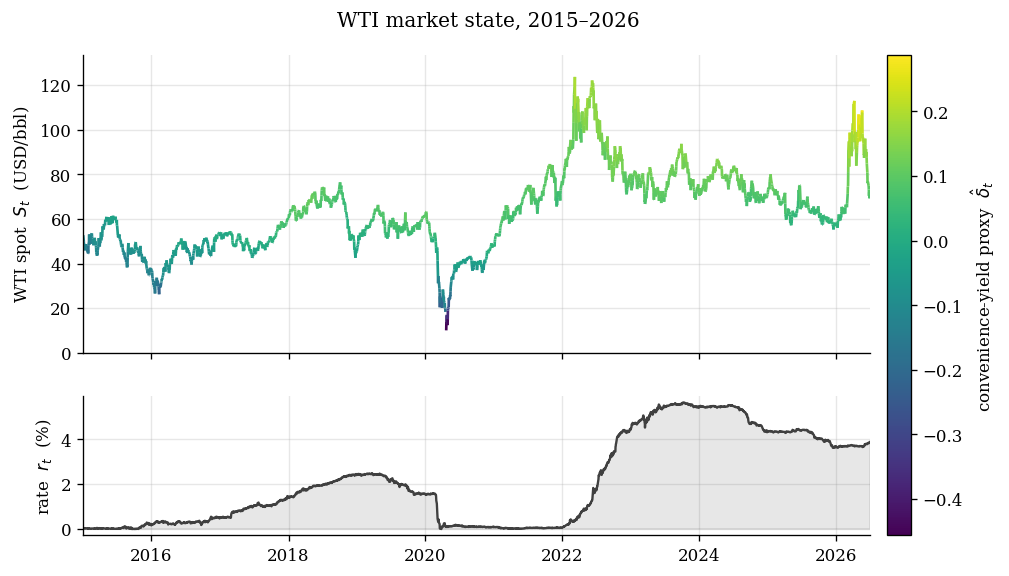

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5.2), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1.4]})

# --- spot, coloured by the delta proxy via a LineCollection --------------
# Build (x,y) segments so each little piece of the line can take its own colour.
x = mdates.date2num(df["date"])
pts  = np.column_stack([x, df["spot"]]).reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)          # (N-1, 2, 2)
lc = LineCollection(segs, cmap=CMAP, linewidth=1.6)
lc.set_array(df["delta_proxy"].to_numpy()[:-1])
ax1.add_collection(lc)
ax1.set_xlim(x.min(), x.max()); ax1.set_ylim(0, df["spot"].max() * 1.08)
ax1.set_ylabel("WTI spot  $S_t$  (USD/bbl)")
cbar = fig.colorbar(lc, ax=[ax1, ax2], pad=0.02, fraction=0.04)
cbar.set_label(r"convenience-yield proxy  $\hat\delta_t$")

# --- risk-free rate ------------------------------------------------------
ax2.plot(df["date"], df["rate"] * 100, color="0.25", linewidth=1.4)
ax2.fill_between(df["date"], df["rate"] * 100, color="0.25", alpha=0.12)
ax2.set_ylabel("rate  $r_t$  (%)")
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("WTI market state, 2015–2026", y=0.95, fontsize=12)
save(fig, "fig1_market_state"); plt.show()

## Figure 2 — Panel geometry: what the PINN actually ingests

**(a)** Each contract traces a descending **sawtooth** in $(\text{date}, \tau)$
space: $\tau$ shrinks linearly toward delivery, then the contract drops out and a
longer-dated one appears. This is the *maturity-rolldown* structure noted in
`CLAUDE.md` — real dated contracts have shrinking $\tau$, unlike the fixed-$\tau$
synthetic panel.

**(b)** The count of live maturities per day (6–9). A PINN observation at date
$t$ is the vector of these points on the curve — never a fixed grid.

saved /Users/evanlynch/Developer/DC-PINNs/notebooks/figures/data/fig2_panel_geometry.{pdf,png}


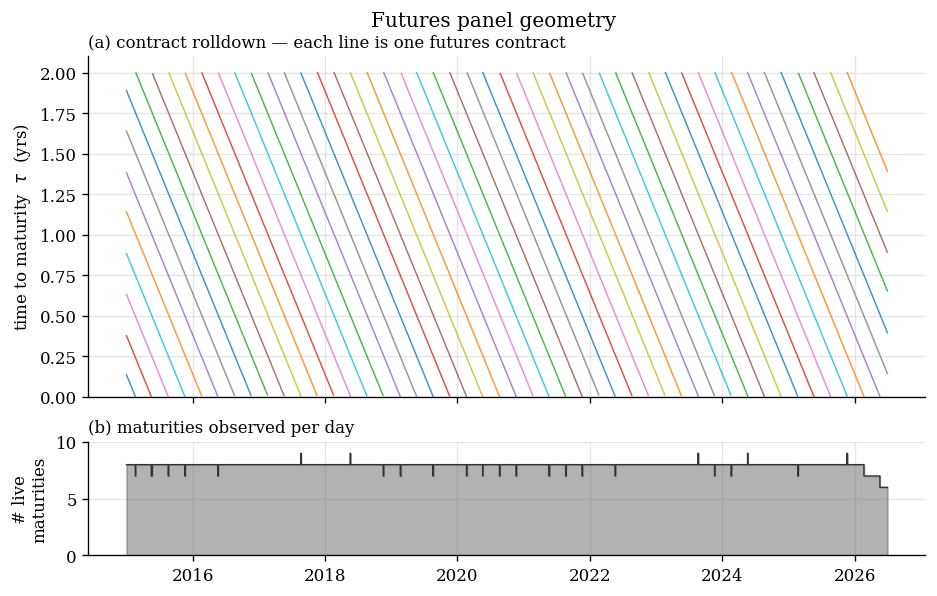

In [13]:
fig, (axa, axb) = plt.subplots(2, 1, figsize=(9, 5.4), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})

# (a) one coloured sawtooth per contract. Colour = maturity month for variety.
for contract, g in panel.groupby("contract"):
    axa.plot(g["date"], g["tau"], linewidth=0.9, alpha=0.8)
axa.set_ylabel(r"time to maturity  $\tau$  (yrs)")
axa.set_title("(a) contract rolldown — each line is one futures contract",
              loc="left", fontsize=10)
axa.set_ylim(0, panel["tau"].max() * 1.05)

# (b) live-maturity count per day.
cnt = panel.groupby("date").size()
axb.fill_between(cnt.index, cnt.values, step="mid", color="0.4", alpha=0.5)
axb.plot(cnt.index, cnt.values, color="0.2", linewidth=0.8, drawstyle="steps-mid")
axb.set_ylabel("# live\nmaturities"); axb.set_ylim(0, cnt.max() + 1)
axb.set_title("(b) maturities observed per day", loc="left", fontsize=10)
axb.xaxis.set_major_locator(mdates.YearLocator(2))
axb.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Futures panel geometry", y=0.95, fontsize=12)
save(fig, "fig2_panel_geometry"); plt.show()

## Figure 3 — 3-D term-structure ribbon  $S \times \tau \times T$

The direct analogue of the reference figure. For each (subsampled) date we draw
the futures curve across its live maturities at that date's position on the time
axis, then stack the curves through time. Colour encodes the **convenience-yield
proxy** $\hat\delta_t$ — so backwardated, high-$\delta$ episodes light up.

We subsample to roughly **biweekly** (~every 10 trading days) so the ~290 curves
read as a ribbon rather than a solid block — the same density as the reference.

saved /Users/evanlynch/Developer/DC-PINNs/notebooks/figures/data/fig3_termstructure_3d.{pdf,png}


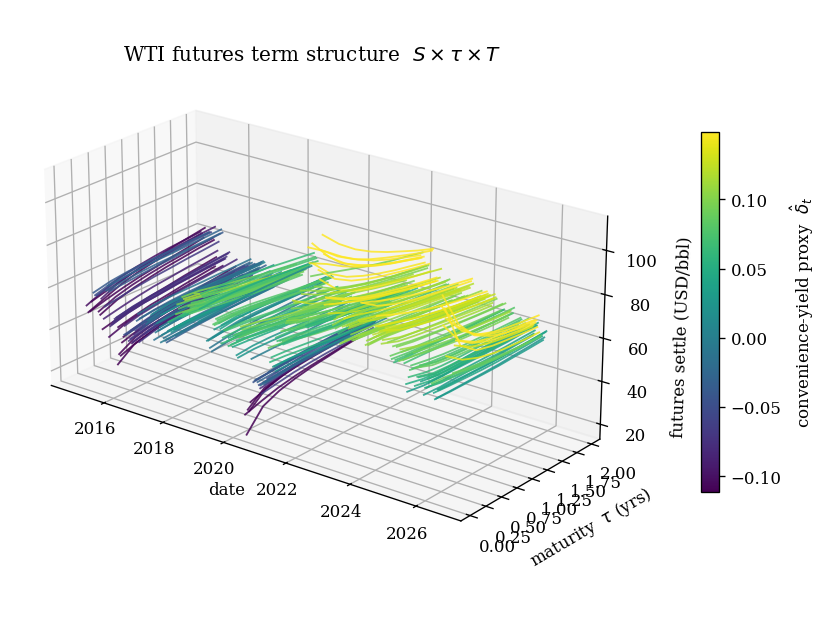

In [23]:
from matplotlib import cm, colors

step  = 10                                   # ~biweekly, matches reference density
dates = df["date"].to_numpy()
sel   = np.arange(0, len(dates), step)
norm  = colors.Normalize(vmin=np.nanpercentile(df["delta_proxy"], 5),
                         vmax=np.nanpercentile(df["delta_proxy"], 95))
smap  = cm.ScalarMappable(cmap=CMAP, norm=norm)

fig = plt.figure(figsize=(9.5, 6.5))
ax  = fig.add_subplot(111, projection="3d")

# x-axis is date (as year float), y is tau, z is settle price.
date_year = df["date"].dt.year + (df["date"].dt.dayofyear - 1) / 365.25
for i in sel:
    d   = dates[i]
    g   = panel[panel["date"] == d].sort_values("tau")
    if len(g) < 2:
        continue
    xs  = np.full(len(g), date_year.iloc[i])
    ys  = g["tau"].to_numpy()
    zs  = g["settle"].to_numpy()
    ax.plot(xs, ys, zs, color=smap.to_rgba(df["delta_proxy"].iloc[i]),
            linewidth=1.1, alpha=0.85)

ax.set_xlabel("date"); ax.set_ylabel(r"maturity  $\tau$ (yrs)")
ax.set_zlabel("futures settle (USD/bbl)")
ax.view_init(elev=22, azim=-52)             # angle chosen so curves don't overlap
ax.set_box_aspect((2.2, 1, 1))
cbar = fig.colorbar(smap, ax=ax, pad=0.10, fraction=0.03, shrink=0.6)
cbar.set_label(r"convenience-yield proxy  $\hat\delta_t$")
ax.set_title(r"WTI futures term structure  $S \times \tau \times T$",
             y=0.98, fontsize=12)
save(fig, "fig3_termstructure_3d"); plt.show()

## Figure 4 — Term-structure heatmap: the basis surface

The 2-D companion to Figure 3, and often the *clearer* read for regime spotting.
For each date we interpolate the curve onto a common $\tau$ grid and plot the
**basis** $F(\tau)/S - 1$:

- **basis $> 0$ (blue-green)** → contango (upward curve; storage-driven);
- **basis $< 0$ (warm)** → backwardation (downward curve; scarcity → high $\delta$).

The two signature episodes stand out: the **deep-contango collapse of April
2020** (solid blue column — storage glut) and the **pronounced backwardation of
2022** (red column — scarcity). These opposite extremes are the convenience-yield
signal the PINN must reconstruct. We use a diverging colormap centred at zero so
the contango/backwardation boundary is unambiguous.

saved /Users/evanlynch/Developer/DC-PINNs/notebooks/figures/data/fig4_basis_heatmap.{pdf,png}


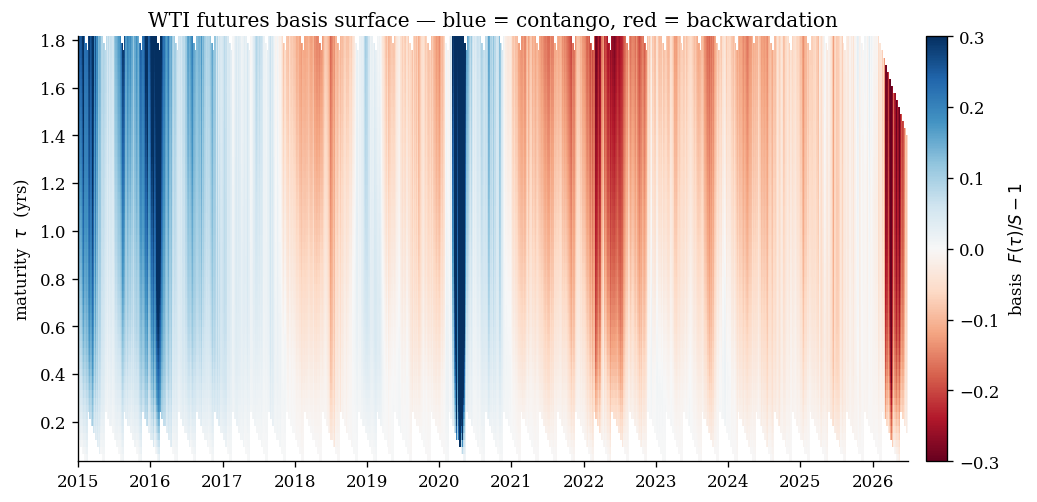

In [15]:
tau_grid = np.linspace(0.05, 1.8, 60)          # common maturity grid (yrs)
rows, row_dates = [], []
spot_by_date = state.set_index("date")["spot"]

for d, g in panel.groupby("date"):
    g = g.sort_values("tau")
    if len(g) < 3 or d not in spot_by_date.index:
        continue
    # Linear interp of settle onto the fixed grid; NaN outside observed tau span
    # so we never fabricate curve where no contracts exist.
    f = np.interp(tau_grid, g["tau"], g["settle"], left=np.nan, right=np.nan)
    rows.append(f / spot_by_date[d] - 1.0)         # basis
    row_dates.append(d)

basis = np.array(rows).T                            # (n_tau, n_dates)
row_dates = pd.to_datetime(row_dates)
vmax = np.nanpercentile(np.abs(basis), 98)          # symmetric limits about 0

fig, ax = plt.subplots(figsize=(9.5, 4.6))
mesh = ax.pcolormesh(row_dates, tau_grid, basis,
                     cmap="RdBu", vmin=-vmax, vmax=vmax, shading="auto")
ax.set_ylabel(r"maturity  $\tau$  (yrs)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(False)
cbar = fig.colorbar(mesh, ax=ax, pad=0.02, fraction=0.04)
cbar.set_label(r"basis  $F(\tau)/S - 1$")
ax.set_title("WTI futures basis surface — blue = contango, red = backwardation",
             fontsize=12)
save(fig, "fig4_basis_heatmap"); plt.show()

## Figure 5 — The model-free convenience-yield proxy $\hat\delta_t$

The punchline of the data chapter: an estimate of **the very quantity the PINN
inverts for**, extracted with nothing more than a curve slope.

Shaded bands mark **backwardation** (curve spread $<0$). The two extremes are
both physically sensible: in **April 2020** $\hat\delta$ *collapses* to $\approx
-0.45$ (super-contango — storage full, no one values holding the physical), while
through **2022** it climbs to $\approx +0.15$ (scarcity → holders of the physical
enjoy a high convenience yield). The sign of $\hat\delta$ tracks the
contango/backwardation regime directly.

**Why this motivates the thesis.** This proxy is one-factor and static: it assumes
a log-linear curve and ignores mean reversion, the $\kappa$–$\lambda$ risk
premium, and curvature. It is **jittery and can go implausibly negative**. The
Gibson–Schwartz PINN replaces this heuristic with a dynamically-consistent,
two-factor inversion — so this figure is both a sanity check *and* the argument
for why the naïve approach is not enough.

saved /Users/evanlynch/Developer/DC-PINNs/notebooks/figures/data/fig5_delta_proxy.{pdf,png}


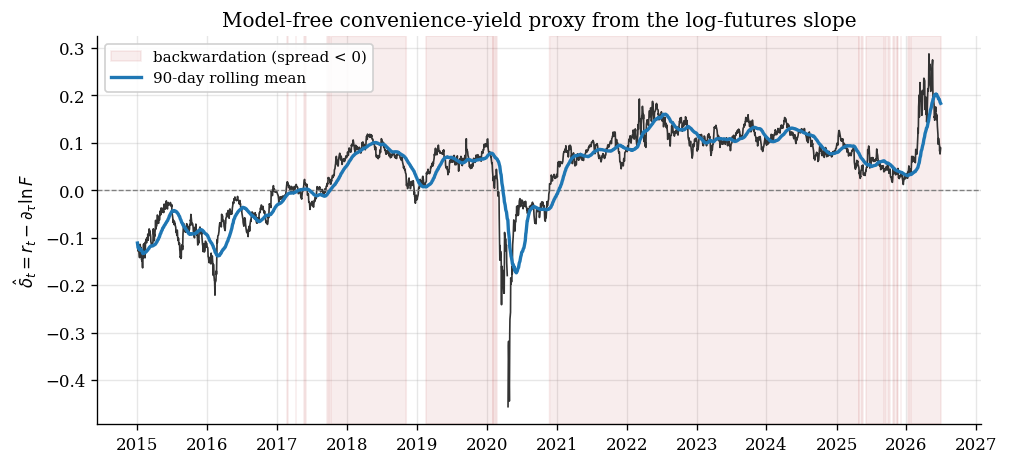

In [16]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))

# Backwardation shading (curve_spread < 0) as a light background band.
back = df["curve_spread"] < 0
ax.fill_between(df["date"], 0, 1, where=back, transform=ax.get_xaxis_transform(),
                color="firebrick", alpha=0.08, step="mid",
                label="backwardation (spread < 0)")

ax.plot(df["date"], df["delta_proxy"], color="0.2", linewidth=1.0)
ax.axhline(0, color="0.5", linewidth=0.8, linestyle="--")

# 63-day (~quarter) rolling mean to expose the low-frequency trend.
roll = df.set_index("date")["delta_proxy"].rolling("90D").mean()
ax.plot(roll.index, roll.values, color="C0", linewidth=2.0,
        label="90-day rolling mean")

ax.set_ylabel(r"$\hat\delta_t = r_t - \partial_\tau \ln F$")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left", framealpha=0.9, fontsize=9)
ax.set_title("Model-free convenience-yield proxy from the log-futures slope",
             fontsize=12)
save(fig, "fig5_delta_proxy"); plt.show()

## Summary

All figures are written to `notebooks/figures/data/` as **vector PDF** (drop
straight into LaTeX with `\includegraphics`) and PNG previews:

| File | Figure |
|------|--------|
| `fig1_market_state`      | spot & rate, coloured by $\hat\delta$ |
| `fig2_panel_geometry`    | contract rolldown + maturities/day |
| `fig3_termstructure_3d`  | 3-D $S\times\tau\times T$ ribbon |
| `fig4_basis_heatmap`     | basis surface (contango/backwardation) |
| `fig5_delta_proxy`       | model-free convenience-yield proxy |

**Suggested extensions if you want more:** a small-multiples grid of the curve on
representative dates (a backwardated day vs a contango day); the front–back
spread histogram; or an ACF of $\hat\delta_t$ to motivate the mean-reversion
speed $\kappa$.